# Proyecto 2 - Detección de objetos con YOLO
## Detección de residuos reciclables

**Integrantes:**  Juan José Betancourt Osorio, Jean Pierre Henriquez Ebrat, Guillermo Alexander Zabala Fernandez
**Curso:** Visión Computacional con Deep Learning  
**Modelo base:** YOLO11s  
**Dataset:** residuos_dataset

### Objetivo
Entrenar un modelo YOLO con transferencia de aprendizaje para detectar tipos de residuos en imágenes y evaluar su desempeño en datos no vistos.


In [1]:
%pip install -q ultralytics opencv-python matplotlib pyyaml pandas pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Contexto del problema

La clasificación manual de residuos puede ser lenta, costosa y propensa a errores, especialmente cuando se busca apoyar procesos de reciclaje en tiempo real. En este proyecto se aborda este problema mediante detección de objetos con visión computacional, con el fin de identificar residuos reciclables en imágenes y videos.

El enfoque seleccionado fue YOLO11s, un modelo de detección de objetos que permite balancear precisión y velocidad de inferencia, lo que lo hace adecuado para escenarios con recursos computacionales limitados.


In [2]:
from ultralytics import YOLO
from pathlib import Path
import yaml
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import random
import os


In [3]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATASET_DIR = PROJECT_ROOT / "data" / "residuos_dataset"
DATA_YAML = DATASET_DIR / "data.yaml"
RUNS_DIR = PROJECT_ROOT / "runs"
MODELS_DIR = PROJECT_ROOT / "models"



print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_DIR:", DATASET_DIR)
print("DATA_YAML:", DATA_YAML)
print("MODELS_DIR:", MODELS_DIR)
print("Existe data.yaml:", DATA_YAML.exists())
print("CUDA disponible:", torch.cuda.is_available())


NOTEBOOK_DIR: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\notebooks
PROJECT_ROOT: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos
DATASET_DIR: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset
DATA_YAML: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\data.yaml
MODELS_DIR: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\models
Existe data.yaml: True
CUDA disponible: True


## Preparación y verificación de datos

Antes del entrenamiento se verificó la estructura del dataset, la existencia de carpetas de imágenes y etiquetas, y la correcta lectura del archivo `data.yaml`. Esta etapa es importante para evitar errores de entrenamiento y asegurar que las anotaciones sean compatibles con el formato esperado por Ultralytics YOLO.

Adicionalmente, se visualizaron muestras del conjunto de entrenamiento para inspeccionar de forma cualitativa la variedad de escenas y objetos presentes en los datos.


In [4]:
with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

data_cfg


{'path': 'C:/Users/jujob/OneDrive/Escritorio/Maestria/Segundo_Semestre/Vision Computacional/Proyecto_2/repo/proyecto_yolo_residuos/data/residuos_dataset',
 'train': 'train/images',
 'val': 'valid/images',
 'test': 'test/images',
 'nc': 7,
 'names': {0: 'Electronics',
  1: 'Glass',
  2: 'Metal',
  3: 'Miscellaneous',
  4: 'Organic',
  5: 'Paper',
  6: 'Plastic'}}

In [5]:
required_paths = [
    DATASET_DIR / "train" / "images",
    DATASET_DIR / "train" / "labels",
    DATASET_DIR / "valid" / "images",
    DATASET_DIR / "valid" / "labels",
    DATASET_DIR / "test" / "images",
    DATASET_DIR / "test" / "labels",
]

for p in required_paths:
    print(p, "->", p.exists())


c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\train\images -> True
c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\train\labels -> True
c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\valid\images -> True
c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\valid\labels -> True
c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\test\images -> True
c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\test\labels -> True


## Descripción del dataset

El dataset utilizado contiene imágenes anotadas en formato YOLO y está organizado en tres subconjuntos: entrenamiento, validación y prueba. Las clases definidas en el archivo `data.yaml` son: Electronics, Glass, Metal, Miscellaneous, Organic, Paper y Plastic.

La distribución del conjunto de datos es la siguiente:
- Entrenamiento: 9116 imágenes.
- Validación: 2302 imágenes.
- Prueba: 1248 imágenes.
- Total: 12666 imágenes.

Esta separación permite entrenar el modelo, ajustar su desempeño con validación y finalmente observar su comportamiento en datos no vistos.


In [6]:
def count_images(folder):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return len([f for f in folder.iterdir() if f.suffix.lower() in exts])

train_count = count_images(DATASET_DIR / "train" / "images")
valid_count = count_images(DATASET_DIR / "valid" / "images")
test_count = count_images(DATASET_DIR / "test" / "images")

print("Train:", train_count)
print("Valid:", valid_count)
print("Test:", test_count)
print("Total:", train_count + valid_count + test_count)


Train: 9116
Valid: 2302
Test: 1248
Total: 12666


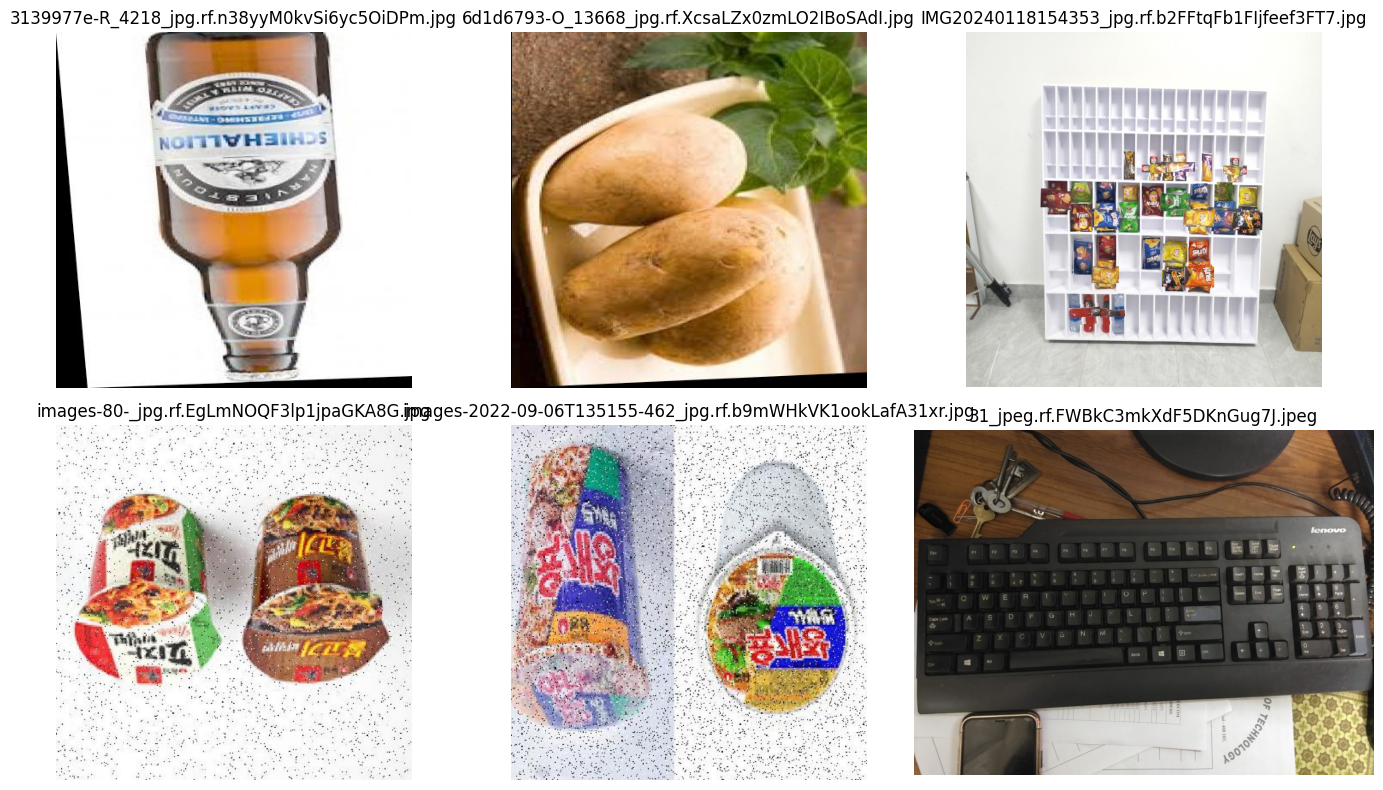

In [7]:
train_images_dir = DATASET_DIR / "train" / "images"
image_files = list(train_images_dir.glob("*.*"))
sample_files = random.sample(image_files, min(6, len(image_files)))

plt.figure(figsize=(14, 8))
for i, img_path in enumerate(sample_files, 1):
    img = Image.open(img_path)
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [8]:
model = YOLO("yolo11s.pt")
model.info()


YOLO11s summary: 181 layers, 9,458,752 parameters, 0 gradients, 21.7 GFLOPs


(181, 9458752, 0, 21.718374400000002)

## Configuración experimental

Se utilizó el modelo preentrenado YOLO11s como punto de partida para aplicar transferencia de aprendizaje sobre el problema de detección de residuos. El entrenamiento se realizó con imágenes de tamaño 640x640, durante 30 épocas, con batch size de 8 y ejecución en GPU NVIDIA GeForce RTX 3060 Laptop GPU de 6 GB.

El uso de pesos preentrenados permite aprovechar conocimiento previo aprendido en tareas de detección general, acelerando la convergencia y mejorando el desempeño frente a un entrenamiento desde cero.


## Observación sobre las anotaciones

Durante la carga del conjunto de validación, Ultralytics reportó una advertencia indicando que el dataset contiene una mezcla entre información de cajas delimitadoras y segmentos (`Box and segment counts should be equal`). Para continuar con el entrenamiento, el framework conservó únicamente las cajas y descartó los segmentos.

Aunque el entrenamiento pudo completarse correctamente, esta advertencia sugiere que una futura mejora del proyecto sería revisar y homogeneizar las anotaciones para mantener un formato completamente consistente.


In [9]:
model = YOLO("yolo11s.pt")

results = model.train(
    data=str(DATA_YAML),
    epochs=50,              # +20 épocas, el modelo aún no plateó
    imgsz=640,
    batch=8,
    pretrained=True,
    project=str(RUNS_DIR),
    name="residuosyolo11s_v2",   # nombre nuevo para no sobreescribir
    val=True,
    plots=True,
    patience=20,
    device=0 if torch.cuda.is_available() else "cpu",
    # ---- Anti-desbalance ----
    cls=2.0,        # penaliza más errores de clasificación (Glass/Plastic)
    mixup=0.15,     # mezcla imágenes → expone más clases raras
    copy_paste=0.1, # copia objetos de clases raras en otras imágenes
    mosaic=1.0,     # ya lo tenías, dejarlo en 1.0
)


New https://pypi.org/project/ultralytics/8.4.30 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.27  Python-3.14.0 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, 

In [22]:
best_model_path = RUNS_DIR / "residuosyolo11s_v2" / "weights" / "best.pt"
last_model_path = RUNS_DIR / "residuosyolo11s_v2" / "weights" / "last.pt"

print("best.pt:", best_model_path, best_model_path.exists())
print("last.pt:", last_model_path, last_model_path.exists())


best.pt: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\runs\residuosyolo11s_v2\weights\best.pt True
last.pt: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\runs\residuosyolo11s_v2\weights\last.pt True


In [23]:
import shutil

final_model_path = MODELS_DIR / "residuosyolo11s_v2.pt"

if best_model_path.exists():
    shutil.copy2(best_model_path, final_model_path)
    print("Modelo copiado a:", final_model_path)
else:
    print("No se encontró best.pt")


Modelo copiado a: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\models\residuosyolo11s_v2.pt


In [24]:
best_model = YOLO(str(final_model_path))
best_model.info()


YOLO11s summary: 182 layers, 9,430,501 parameters, 0 gradients, 21.6 GFLOPs


(182, 9430501, 0, 21.5613952)

In [25]:
metrics = best_model.val(data=str(DATA_YAML))
metrics


Ultralytics 8.4.27  Python-3.14.0 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
YOLO11s summary (fused): 101 layers, 9,415,509 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 138.484.9 MB/s, size: 74.5 KB)
val: Scanning C:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\valid\labels.cache... 2302 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2302/2302 643.7Mit/s 0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 4, len(boxes) = 3720. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 144/144 5.4it/s 26.7s0.2s
                   all       2302       3720      0.925      0.855 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000020720928280>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

In [30]:
results_csv = RUNS_DIR / "residuosyolo11s_v2" / "results.csv"
df = pd.read_csv(results_csv)
df.head()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,230.484,1.21808,7.71671,1.62694,0.56485,0.48718,0.50076,0.29732,1.67081,7.45679,2.23387,0.000303,0.000303,0.000303
1,2,421.774,1.24905,6.88623,1.67494,0.58566,0.46680,0.50518,0.28492,1.59775,7.44631,1.93768,0.000594,0.000594,0.000594
2,3,601.029,1.22852,6.79384,1.66465,0.60436,0.48783,0.54191,0.32499,1.55526,7.22820,1.92460,0.000873,0.000873,0.000873
3,4,784.588,1.19221,6.40105,1.63234,0.58051,0.49171,0.53542,0.33325,1.45831,7.03417,1.82298,0.000855,0.000855,0.000855
4,5,969.433,1.16042,6.09428,1.60213,0.57324,0.59481,0.60573,0.37150,1.47403,6.49585,1.86002,0.000837,0.000837,0.000837


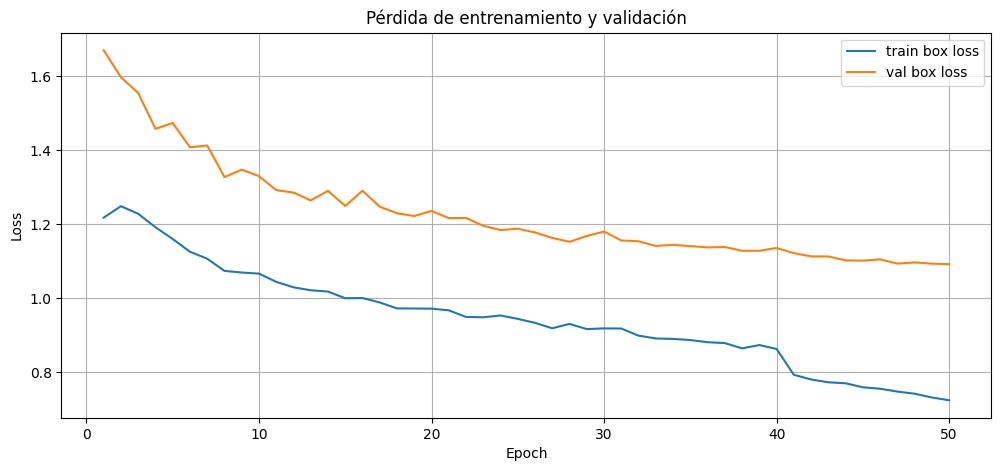

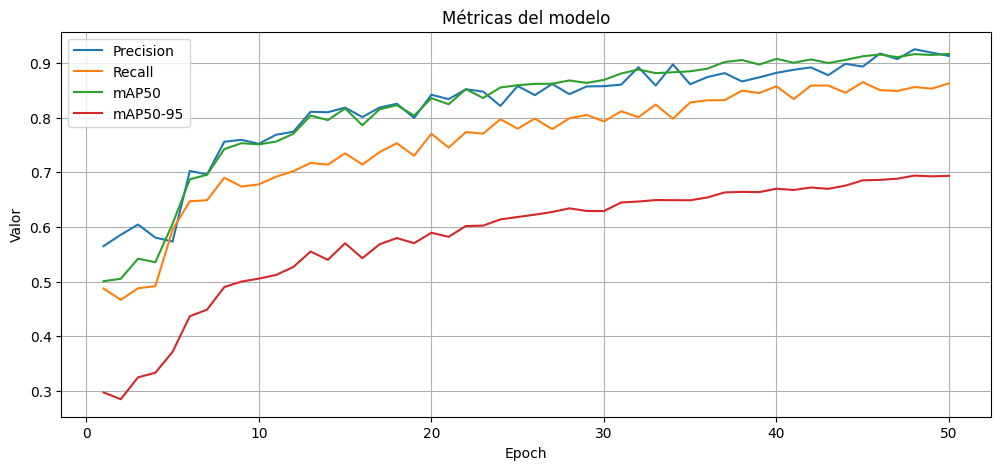

In [31]:
plt.figure(figsize=(12, 5))
plt.plot(df["epoch"], df["train/box_loss"], label="train box loss")
plt.plot(df["epoch"], df["val/box_loss"], label="val box loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Pérdida de entrenamiento y validación")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("Valor")
plt.title("Métricas del modelo")
plt.legend()
plt.grid(True)
plt.show()


## Interpretación de resultados de entrenamiento

Las curvas de entrenamiento permiten observar una reducción progresiva de las pérdidas, junto con una mejora sostenida en las métricas de validación. Esto sugiere que el modelo logró aprender patrones relevantes del dataset sin mostrar un comportamiento claramente inestable durante las épocas ejecutadas.

En particular, el aumento de métricas como precisión, recall y mAP refleja que el modelo fue mejorando tanto en la localización de objetos como en su clasificación.


In [32]:
test_images = list((DATASET_DIR / "test" / "images").glob("*.*"))
sample_test_image = test_images[0]

print("Imagen de prueba:", sample_test_image)

pred = best_model.predict(
    source=str(sample_test_image),
    conf=0.25,
    save=True,
    project=str(RUNS_DIR),
    name="predict_test_image",
    exist_ok=True
)


Imagen de prueba: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\test\images\002ba7cf-R_3775_jpg.rf.EZ7mVdoSKtNROIwWtkrg.jpg

image 1/1 c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\test\images\002ba7cf-R_3775_jpg.rf.EZ7mVdoSKtNROIwWtkrg.jpg: 640x640 1 Paper, 62.0ms
Speed: 4.8ms preprocess, 62.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\runs\predict_test_image


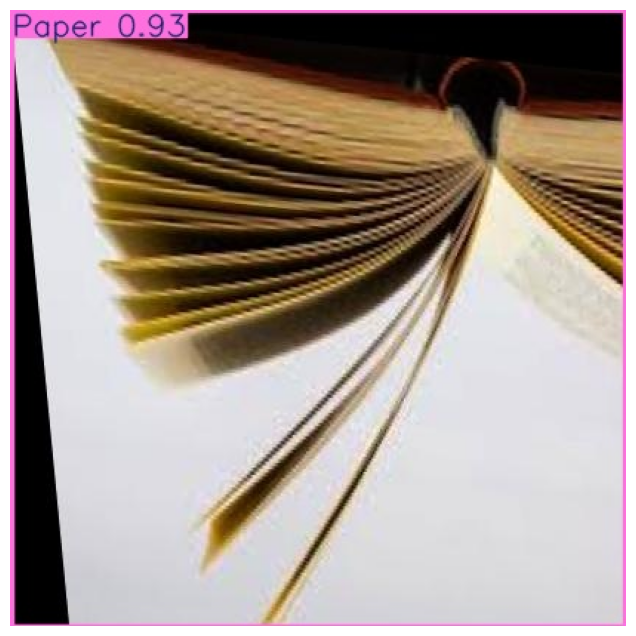

In [33]:
predicted_img_path = RUNS_DIR / "predict_test_image" / sample_test_image.name
img = Image.open(predicted_img_path)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.show()


In [34]:
predictions = best_model.predict(source=str(sample_test_image), conf=0.25)
class_names = best_model.names

for pred in predictions:
    for box, conf, cls in zip(pred.boxes.xyxy, pred.boxes.conf, pred.boxes.cls):
        print(
            "Clase:", class_names[int(cls.item())],
            "| Confianza:", round(conf.item(), 4),
            "| Box:", [round(x, 2) for x in box.tolist()]
        )



image 1/1 c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\test\images\002ba7cf-R_3775_jpg.rf.EZ7mVdoSKtNROIwWtkrg.jpg: 640x640 1 Paper, 111.9ms
Speed: 4.7ms preprocess, 111.9ms inference, 3.3ms postprocess per image at shape (1, 3, 640, 640)
Clase: Paper | Confianza: 0.934 | Box: [1.94, 0.65, 415.9, 416.0]


## Resultados cualitativos

Además de las métricas numéricas, se realizó una evaluación visual del modelo sobre imágenes y video. Esta inspección permite verificar si las detecciones generadas son coherentes con el contenido real de la escena y si el modelo mantiene un comportamiento razonable fuera del conjunto de entrenamiento.

Las predicciones observadas muestran que el modelo es capaz de identificar residuos como Paper, Organic y Plastic en ejemplos no vistos, lo que evidencia su utilidad práctica como sistema de apoyo para clasificación automática.


In [35]:
video_path = PROJECT_ROOT / "test_video_2.mp4"

if video_path.exists():
    best_model.predict(
        source=str(video_path),
        conf=0.25,
        save=True,
        project=str(RUNS_DIR),
        name="predict_video",
        exist_ok=True
    )
    print("Video procesado.")
else:
    print("No existe test_video_2.mp4 en la raíz del proyecto.")



WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/231) c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\test_video_2.mp4: 640x384 1 Plastic, 72.2ms
video 1/1 (frame 2/231) c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\test_video_2.mp4: 640x384 1 Organic, 1 Plastic, 65.3ms
video 1/1 (frame 3/231) c:\Users\jujob\OneDrive\Escritorio\Maestria\Segu

In [37]:
# Ejecutar esta celda solo para probar con camara
best_model.predict(source=0, show=True, conf=0.4)



1/1: 0... Success  (inf frames of shape 640x480 at 30.00 FPS)

WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

0: 480x640 1 Electronics, 11.2ms
0: 480x640 1 Electronics, 10.9ms
0: 480x640 1 Electronics, 16.7ms
0: 480x640 1 Electronics, 11.0ms
0: 480x640 1 Electronics, 11.0ms
0: 480x640 1 Electronics, 10.8ms
0: 480x640 (no detections), 10.8ms
0: 480x640 1 Electronics, 11.1ms
0: 480x640 1 Electronics, 10.8ms
0: 480x640 (no detections), 10.8ms
0: 480x640 (no detections), 11.0ms
0: 480x640 (no detections), 1

KeyboardInterrupt: 

## Conclusiones

- Se logró entrenar un modelo de detección de objetos basado en YOLO11s para identificar 7 clases de residuos reciclables: Electronics, Glass, Metal, Miscellaneous, Organic, Paper y Plastic.

- El experimento se desarrolló sobre un dataset de 12666 imágenes, distribuido en 9116 para entrenamiento, 2302 para validación y 1248 para prueba, lo que proporcionó una base suficiente para evaluar el comportamiento del modelo.

- El desempeño del modelo mejoró de forma progresiva durante el entrenamiento. En las últimas épocas de validación se alcanzaron valores cercanos a 0.86 en precisión, 0.775 en recall, 0.865 en mAP50 y 0.644 en mAP50-95, lo que indica un resultado sólido para una primera aproximación al problema.

- Las pruebas cualitativas sobre imágenes y video mostraron detecciones coherentes en clases como Paper, Organic y Plastic, lo que sugiere que el modelo no solo aprendió en términos métricos, sino que también puede generalizar razonablemente a ejemplos no vistos.

- Como limitación principal, se identificó una inconsistencia en las anotaciones del dataset, ya que Ultralytics reportó mezcla entre cajas y segmentos. Aunque el entrenamiento continuó utilizando solo cajas, esta situación puede afectar la limpieza experimental y debería corregirse en una versión futura.

- Como trabajo futuro, sería conveniente revisar y depurar las etiquetas, analizar el desempeño por clase, probar variantes adicionales de YOLO y comparar resultados con configuraciones distintas de tamaño de imagen, batch size o número de épocas.
